# **Data-Driven Mapping of the ASEAN Higher Education Landscape Based on 2026 University Ranking Data**
## **Jose Isagani B. Janairo**
### **Github repository: [AIM Capstone](https://github.com/jijanairo/AIMcapstone.git)**

### **Study Background**
In the Asian region, particularly within the ASEAN, higher education institutions (HEIs) or universities take international rankings seriously. These global rankings heavily dictate public perception which translates into prestige, student enrollment, and funding security. In the Philippines, for example, a deeply entrenched socio-economic bias exists favoring graduates of the traditional "Big Four" universities. Crucially, these same four institutions consistently emerge as the top-ranked Philippine HEIs across various international ranking frameworks. This intersection demonstrates that rankings are not merely vanity metrics; they are powerful gatekeepers that institutionalize prestige and drive downstream labor market advantages and resource allocation.

### **Problem Statement and Study Objectives**
Considering the importance of international rankings for HEIs in the ASEAN region, university administrators allocate resources and manpower to activites and strategies that may improve their international rankings. In practice, it is not uncommon for universities to evaluate the ranking methodology, study the criteria weights, look at institutional ranking scorecard, and focus on the criterion in which the particular university lags. Alternatively, some institutions attempt to simultaneously enhance all performance metrics. However, these approaches are anchored on the flawed linear assumption of the ranking system. In reality, competitive advancement is non-linear and highly relative. In order to effectively move up the hierarchy, an institution must evaluate its position relative to its immediate multi-dimensional "neighbors" within the data landscape.

### Objectives
The primary objective of this study is to map the non-linear, multi-dimensional landscape of top-ranked ASEAN Higher Education Institutions (HEIs) based on the latest QS World University Ranking data, and determine performance metrics that influence the upward institutional mobility. **Specifically,** this study aims to:

1) Use exploratory data analysis and unsupervised clustering to identify segments among top-ranked ASEAN HEIs, and determine which performance metrics are drivers of segmentation. (Success metrics: Clustering quality - elbow method and silhouette score)

2) Evaluate the statistical variance across the discovered HEI segments using One-Way ANOVA and Tukey’s HSD post-hoc tests to determine which specific institutional attributes (such as research velocity, prestige, or physical scale) drive the static differences between these "neighborhoods." (Success metric: statistical signficance and comprehensive post-hoc test results matrix)

3) Fit a penalized logistic regression to the data and identify the most impactful and actionable institutional performance metrics that can be optimized for upward tier mobility. (Success matrix: AUC and odds ratio)

### **Dataset Overview**
The dataset was obtained from the [2026 QS World University Rankings](https://www.topuniversities.com/asia-university-rankings), with filters applied to limit institutions belonging to the ASEAN region. The data was downloaded last June 19, 2026. The filtered dataset has 255 rows (universities) and 15 columns (university attributes).

### **Data Dictionary**
The following are the variables in the dataset used in this study.

*1. Institution*: The universities in ASEAN that are included in the 2026 QS World University Rankings. The entries are string.

*2. Rank*: The rank of the institutions in the 2026 QS World University Rankings. The entries are numerical and ordinal.

*3. Class*: This is an author-derived categorization of the variable *Institution*. The categorization is based on the *Rank* of the *Institution*, wherein universities that are ranked from 1 - 700 are designated to class A. On the other hand, universities that are ranked 700 and higher (1501+), which are often banded together, are classified to Class B. Universities in Class A can thus be considered as part of the elite tier whereas Class B universities are those in the emerging tier.

 *4. Country*: The country where the Institution is located.

 *5. Size*: The physical size of the Institution. It is a categorical variable that takes the following entries: S (small), M (medium), L (large), XL (extra-large).

 *6. Academic*: This numeric variable represents academic reputation, which has possible values ranging from 0 - 100.

 *7. Employer* This numeric variable represents employer reputation, which has possible values ranging from 0 - 100.

 *8. Faculty student*: This numeric variable represents the faculty - student ratio of the university, which has possible values ranging from 0-100.

 *9. IRN*: This variable stands for International Research Network of the university, which is a measure of success of the university in forming and maintaining research partnerships in different locations. This numeric variable has possible ranges of 0 - 100.

 *10. Citations per paper*: This numeric variable which ranges from 0-100 shows the citations per paper in percentage of faculty members in a given institution.

 *11. Papers per faculty*: This numeric variable which ranges from 0-100 shows the number of published journal articles per faculty member in a given institution.

 *12. Staff with PhD*: This numeric variable which ranges from 0-100 shows the number of staff members with PhD in a given institution.

 *13. International faculty*: This numeric variable which ranges from 0 - 100 shows the ratio of international faculty members to all staff in a given institution.

 *14. International students*:This numeric variable which ranges from 0 - 100 shows the ratio of international students in a given institution.

 *15. Inbound*: This numeric variable which ranges from 0 - 100 shows the percentage of students enrolled in a foreign university that spends at least a semester in the specified university.

 *16. Outbound*: This numeric variable which ranges from 0 - 100 shows the percentage of students enrolled in one of the ranked ASEAN universities  that spends at least a semester in a foreign institution.

### **Data loading and quality check**

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
os.chdir('/Users/COS/Documents/AIM/Capstone')

# ---SET THEME FOR PYCHARM DARK MODE ---
plt.style.use('default')  # Reset to standard defaults

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': '#FFFFFF',   # Canvas background stays white
    'figure.edgecolor': '#FFFFFF',
    'axes.facecolor': '#FFFFFF',     # Inner chart stays white
    'savefig.facecolor': '#FFFFFF',
    'savefig.edgecolor': '#FFFFFF',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',      # Axis labels stay black for white chart contrast
    'xtick.color': 'black',          # Ticks stay black for white chart contrast
    'ytick.color': 'black',
})

# --- LOAD DATA ---
df = pd.read_csv('qs.csv', encoding='latin1')
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")



Dataset Shape: 255 rows, 16 columns



--- 3.1 HIGH-LEVEL STRUCTURAL CHECK ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Institution             255 non-null    object 
 1   Rank                    255 non-null    object 
 2   Class                   255 non-null    object 
 3   Country                 255 non-null    object 
 4   Size                    255 non-null    object 
 5   Academic                255 non-null    float64
 6   Employer                244 non-null    float64
 7   Faculty student         249 non-null    float64
 8   IRN                     242 non-null    float64
 9   Citations per paper     243 non-null    float64
 10  Papers per faculty      247 non-null    float64
 11  Staff with PhD          211 non-null    float64
 12  International faculty   189 non-null    float64
 13  International students  208 non-null    float64
 14  In

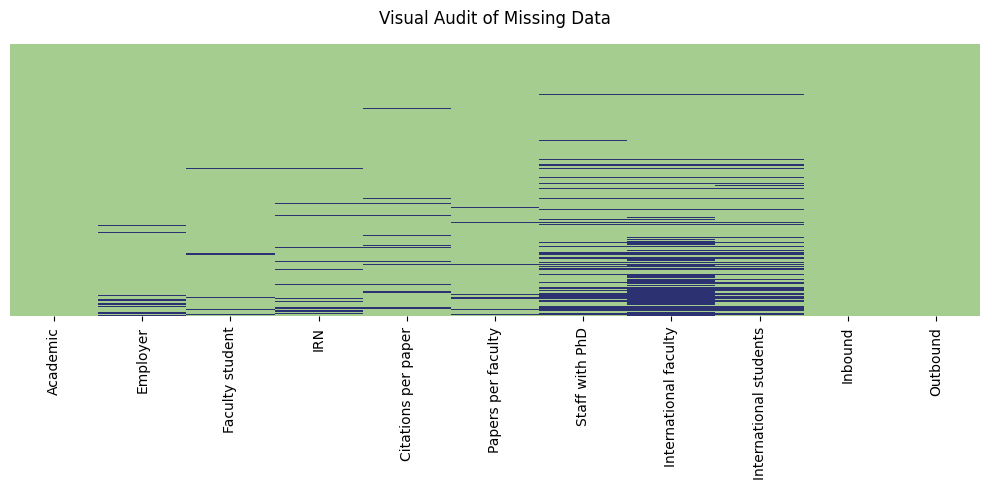

In [2]:
import seaborn as sns

# SEPARATE METRIC COLUMNS & TARGET
# The 11 continuous QS indicators
indicator_cols = [
    'Academic', 'Employer', 'Faculty student', 'IRN',
    'Citations per paper', 'Papers per faculty', 'Staff with PhD',
    'International faculty', 'International students', 'Inbound', 'Outbound'
]

# Metadata/Categorical columns
meta_cols = ['Institution', 'Rank', 'Class', 'Country', 'Size']

print("--- 3.1 HIGH-LEVEL STRUCTURAL CHECK ---")
print(df.info())
print("\n" + "="*50 + "\n")


print("--- 3.2 TARGET VARIABLE BALANCE ---")
# Verifying that Class A (Elite) and Class B (Banded) are balanced
class_counts = df['Class'].value_counts()
class_pcts = df['Class'].value_counts(normalize=True) * 100
for idx in class_counts.index:
    print(f"Class {idx}: {class_counts[idx]} universities ({class_pcts[idx]:.2f}%)")
print("\n" + "="*50 + "\n")


print("--- 3.3 GEOGRAPHIC DISTRIBUTION ---")
# Understanding country representation to watch out for sample dominance
country_counts = df['Country'].value_counts()
print(country_counts.to_string())
print("\n" + "="*50 + "\n")


print("--- 3.4 MISSING DATA ANALYSIS ---")
# Calculating exact null counts and percentages per indicator
missing_df = pd.DataFrame({
    'Null Count': df[indicator_cols].isnull().sum(),
    'Null Percentage (%)': df[indicator_cols].isnull().mean() * 100
}).sort_values(by='Null Percentage (%)', ascending=False)

print("Missing data per indicator:")
print(missing_df.to_string())

# Crucial Check: Is missingness significantly correlated with Class B?
print("\nProportion of missing entries occurring in Class B vs Class A:")
for col in indicator_cols:
    if df[col].isnull().sum() > 0:
        b_missing = df[df['Class'] == 'B'][col].isnull().sum()
        total_missing = df[col].isnull().sum()
        print(f"  - {col}: {b_missing}/{total_missing} ({b_missing/total_missing*100:.1f}%) of missing values are in Class B.")
print("\n" + "="*50 + "\n")


print("--- 3.5 SKEWNESS & OUTLIER DETECTION ---")
# Calculating skewness (Skew > 1 or < -1 indicates a heavily distorted distribution)
skewness = df[indicator_cols].skew()
print("Skewness of raw indicators:")
print(skewness.sort_values(ascending=False).to_string())

# Identifying potential outliers using the Interquartile Range (IQR) method
print("\nPotential Outlier Count per feature (Beyond 1.5 * IQR):")
for col in indicator_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  - {col}: {len(outliers)} possible outlier(s)")
print("\n" + "="*50 + "\n")


# 4. VISUALIZATION (DATA AUDIT)
# Generating a quick heatmap of missingness to view in your notebook environment

fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
ax.set_facecolor('white')  # Double check inner axes background

# Draw heatmap cleanly
sns.heatmap(df[indicator_cols].isna(), cbar=False, cmap='crest', yticklabels=False, ax=ax)

plt.title('Visual Audit of Missing Data', color='black', fontsize=12, pad=15)
plt.tight_layout()

# Save a pristine, high-res copy directly to your capstone folder
plt.savefig('missing_data_heatmap.png', dpi=300, facecolor=fig.get_facecolor(), edgecolor='none')

plt.show()

### **Unsupervised Clustering**
#### Relevant modules: 2, 7 & 8
In this section, k-means clustering was pplied to the university ranking data in order to identify distinct institutional tiers. The missing data was imputed using the median value, and the resulting dataset was used for subsequent cluster analysis.  Both the elbow and silhouette methods were used to determine the optimal number of clusters. Cluster memberships were visualized using PCA projections. It should be emphasized the 12 variables were used for clustering and PCA projections were used to visualize the clusters.


Dataset Shape Verified: (255, 12) (All 255 Universities Loaded)
Diagnostics complete! Validation plot saved as: 'kmeans_optimization_diagnostics.png'

             VARIABLE LOADINGS MATRIX PER PC            
                        PC1_Loading  PC2_Loading
Academic                     0.3288       0.2941
Employer                     0.3309       0.2605
Citations per paper          0.1988       0.0634
Papers per faculty           0.2955       0.1456
IRN                          0.3045       0.3896
International faculty        0.2918      -0.2865
International students       0.2830      -0.3622
Inbound                      0.3138      -0.1807
Outbound                     0.3259      -0.1811
Faculty student              0.3111      -0.1565
Staff with PhD               0.3052       0.0851
Size_encoded                -0.0545       0.5984

             UNIVERSITY CLUSTER MEMBERSHIPS LIST        
 Assigned_Cluster                                                                University
     

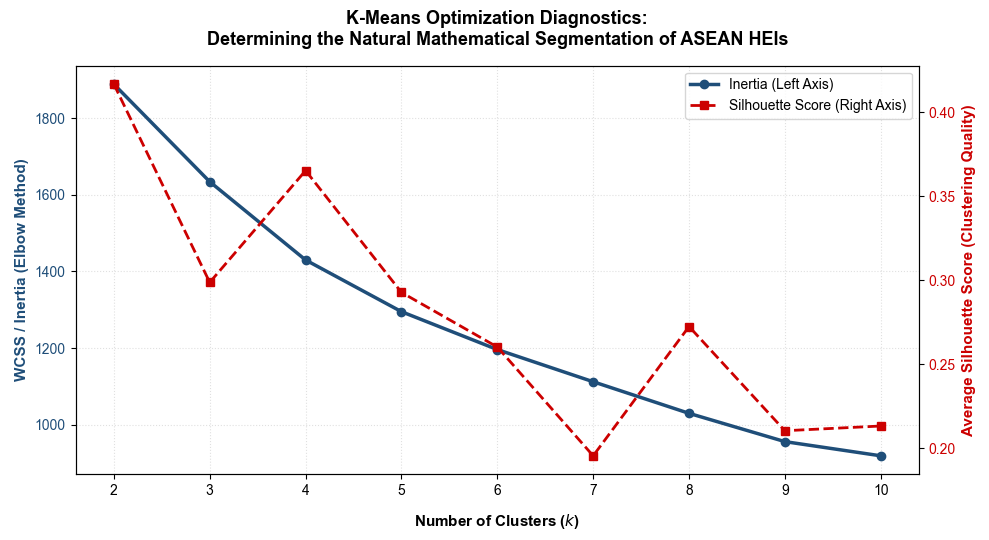

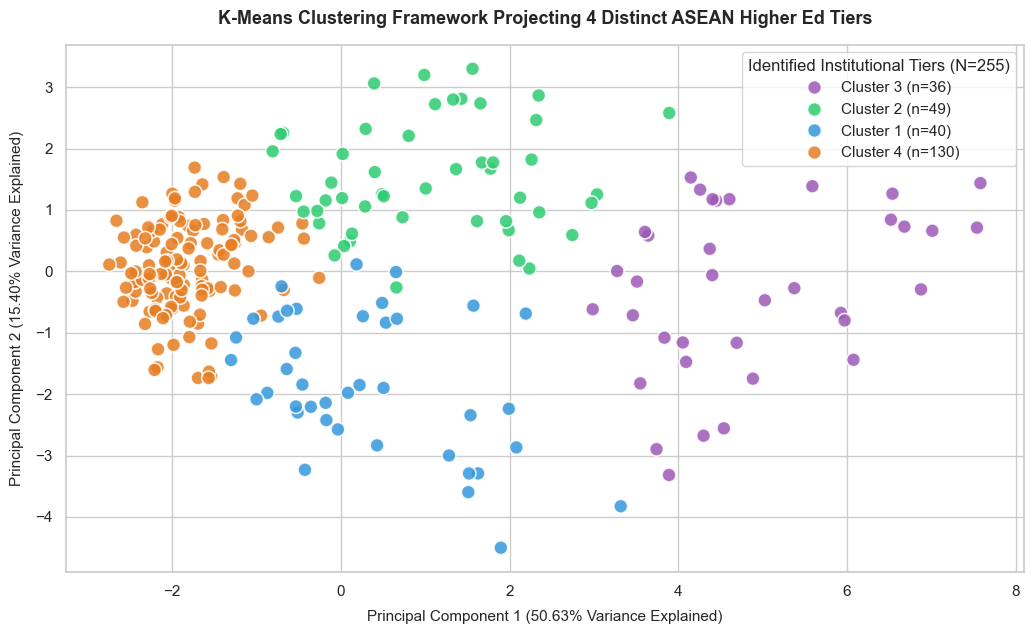

In [23]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 1. GLOBAL INITIALIZATION, WORKING DIRECTORY & SETUP ---
warnings.filterwarnings("ignore")
os.chdir("/Users/COS/Documents/AIM/Capstone")

# --- 2. DATA INGESTION & COHORT FEATURE ENCODING ---
try:
    df = pd.read_csv("qs.csv", encoding="latin1")
except UnicodeDecodeError:
    df = pd.read_csv("qs.csv", encoding="cp1252")

# Create the categorical size encoding required for the clustering pipeline
df["Size_encoded"] = df["Size"].map({"S": 1, "M": 2, "L": 3, "XL": 4})

# Define all 12 independent features for the institutional topology analysis
independent_features = [
    'Academic', 'Employer',                           # Reputational
    'Citations per paper', 'Papers per faculty',       # Research
    'IRN', 'International faculty', 'International students',
    'Inbound', 'Outbound',                             # Internationalization
    'Faculty student', 'Staff with PhD',               # Capacity
    'Size_encoded'                                     # Structure
]

# Isolate raw data and apply Median Imputation consistently
X_raw = df[independent_features].copy()
X_imputed = X_raw.fillna(X_raw.median())

print(f"Dataset Shape Verified: {X_imputed.shape} (All 255 Universities Loaded)")

# Standardize features to mean=0 and variance=1 for distance-based math
X_scaled = StandardScaler().fit_transform(X_imputed)

# Setup baseline dataframe for plot coordinates
df_spatial = pd.DataFrame()

# =====================================================================
# 3. K-MEANS OPTIMIZATION DIAGNOSTICS (MULTIDIMENSIONAL SPACE)
# =====================================================================
wcss = []
silhouette_avg = []
k_range = range(2, 11)

# Fit diagnostic calculations on all 12 variables to ensure topological accuracy
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans_test.fit(X_scaled)
    wcss.append(kmeans_test.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, kmeans_test.labels_))

# Generate Dual-Axis Diagnostic Plot
fig_diag, ax1 = plt.subplots(figsize=(10, 5.5))
plt.style.use("default")

color = '#1f4e79'
ax1.set_xlabel('Number of Clusters ($k$)', fontweight='bold', fontsize=11, labelpad=10)
ax1.set_ylabel('WCSS / Inertia (Elbow Method)', color=color, fontweight='bold', fontsize=11)
line1 = ax1.plot(k_range, wcss, marker='o', color=color, linewidth=2.5, label='Inertia (Left Axis)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6, color='#cccccc')

ax2 = ax1.twinx()
color = '#cc0000'
ax2.set_ylabel('Average Silhouette Score (Clustering Quality)', color=color, fontweight='bold', fontsize=11)
line2 = ax2.plot(k_range, silhouette_avg, marker='s', color=color, linestyle='--', linewidth=2, label='Silhouette Score (Right Axis)')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True)

plt.title('K-Means Optimization Diagnostics:\nDetermining the Natural Mathematical Segmentation of ASEAN HEIs',
          fontsize=13, fontweight='bold', pad=15)
fig_diag.tight_layout()

output_diag_path = "kmeans_optimization_diagnostics.png"
plt.savefig(output_diag_path, dpi=300, bbox_inches='tight')
print(f"Diagnostics complete! Validation plot saved as: '{output_diag_path}'")


# =====================================================================
# 4. EXECUTE FINAL MODEL ON FULL FEATURE SPACE (K = 4)
# =====================================================================
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, n_init='auto', random_state=42)

# Train on 100% of your 12 scaled structural variables to eliminate distortion
true_12d_labels = kmeans_final.fit_predict(X_scaled)

# Shift labels to formal 1-indexed convention [1, 2, 3, 4]
cluster_labels = true_12d_labels + 1

# Assign cluster targets to tracking datasets safely
df['Assigned_Cluster'] = cluster_labels
if isinstance(X_imputed, np.ndarray):
    X_imputed = pd.DataFrame(X_imputed, columns=independent_features)
X_imputed['Assigned_Cluster'] = cluster_labels
df_spatial['Cluster_Num'] = cluster_labels


# =====================================================================
# 5. GENERATE THE NEW PCA LAYOUT CODES FOR VISUALIZATION ONLY
# =====================================================================
# PCA is now strictly used as a camera lens to view the 12D clusters in 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_spatial['PC1'] = X_pca[:, 0]
df_spatial['PC2'] = X_pca[:, 1]

# Print Variable Loadings Matrix
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1_Loading', 'PC2_Loading'],
    index=independent_features
)
print("\n" + "="*60)
print("             VARIABLE LOADINGS MATRIX PER PC            ")
print("="*60)
print(loadings.round(4))
print("="*60 + "\n")

# Dynamic mapping of descriptive labels for the scatter legend
unique_clusters, counts = np.unique(cluster_labels, return_counts=True)
counts_dict = dict(zip(unique_clusters, counts))
cluster_names = {i: f"Cluster {i} (n={counts_dict.get(i, 0)})" for i in unique_clusters}
df_spatial['Cluster'] = df_spatial['Cluster_Num'].map(cluster_names)

# Print University Group Roster
univ_col = 'Institution' if 'Institution' in df.columns else df.columns[0]
df_membership = pd.DataFrame({
    'University': df[univ_col],
    'Assigned_Cluster': cluster_labels,
    'PC1_Coordinate': X_pca[:, 0],
    'PC2_Coordinate': X_pca[:, 1]
}).sort_values(by=['Assigned_Cluster', 'University'])

print("="*60)
print("             UNIVERSITY CLUSTER MEMBERSHIPS LIST        ")
print("="*60)
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df_membership[['Assigned_Cluster', 'University']].to_string(index=False))
print("="*60 + "\n")


# =====================================================================
# 6. GENERATE GEOSPATIAL TIERS MAP (EXPANDED PALETTE)
# =====================================================================
plt.figure(figsize=(10.5, 6.5))
sns.set_theme(style="whitegrid")

# Expanded palette to beautifully support up to 4 clusters natively
palette = {
    cluster_names.get(1, 'C0'): '#3498db',  # Cluster 1: Muted Blue
    cluster_names.get(2, 'C1'): '#2ecc71',  # Cluster 2: Soft Green
    cluster_names.get(3, 'C2'): '#9b59b6',  # Cluster 3: Rich Purple
    cluster_names.get(4, 'C3'): '#e67e22'   # Cluster 4: Warm Amber / Orange
}

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

sns.scatterplot(
    data=df_spatial,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette=palette,
    alpha=0.85,
    s=100,
    edgecolor='w',
    linewidth=1.2
)

plt.title('K-Means Clustering Framework Projecting 4 Distinct ASEAN Higher Ed Tiers', fontsize=13, pad=15, weight='bold')
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}% Variance Explained)', fontsize=11, labelpad=8)
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}% Variance Explained)', fontsize=11, labelpad=8)
plt.legend(title='Identified Institutional Tiers (N=255)', loc='upper right', frameon=True)
plt.tight_layout()

output_plot_path = "asean_universities_kmeans_pca.png"
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"Success! High-resolution 4-cluster map figure saved as: '{output_plot_path}'\n")

plt.show()

The elbow plot suggests k = 4 or 5 whereas the silhoutte method showed that 4 is the optimum number of clusters. Hence the number of clusters was set to 4. Cluster memberships and visualization are shown above. The average values and standard deviation of each variable for each cluster is shown below. One-way ANOVA was also conducted and the results are visualized as well.

             CLUSTER DESCRIPTIVE PROFILES (MEAN ± STANDARD DEVIATION)       

--- Feature: ACADEMIC ---
  Cluster 1: Mean =  28.76 | Std Dev =  16.13
  Cluster 2: Mean =  49.89 | Std Dev =  22.65
  Cluster 3: Mean =  77.01 | Std Dev =  20.66
  Cluster 4: Mean =  15.27 | Std Dev =  13.17

--- Feature: EMPLOYER ---
  Cluster 1: Mean =  26.18 | Std Dev =  17.46
  Cluster 2: Mean =  52.50 | Std Dev =  29.11
  Cluster 3: Mean =  76.88 | Std Dev =  23.55
  Cluster 4: Mean =  11.41 | Std Dev =   9.28

--- Feature: CITATIONS PER PAPER ---
  Cluster 1: Mean =  16.29 | Std Dev =  24.84
  Cluster 2: Mean =  38.42 | Std Dev =  33.34
  Cluster 3: Mean =  28.17 | Std Dev =  31.00
  Cluster 4: Mean =   9.15 | Std Dev =  17.10

--- Feature: PAPERS PER FACULTY ---
  Cluster 1: Mean =   8.43 | Std Dev =   7.91
  Cluster 2: Mean =  21.54 | Std Dev =  20.98
  Cluster 3: Mean =  30.74 | Std Dev =  22.04
  Cluster 4: Mean =   4.28 | Std Dev =   2.71

--- Feature: IRN ---
  Cluster 1: Mean =  39.86 | Std Dev

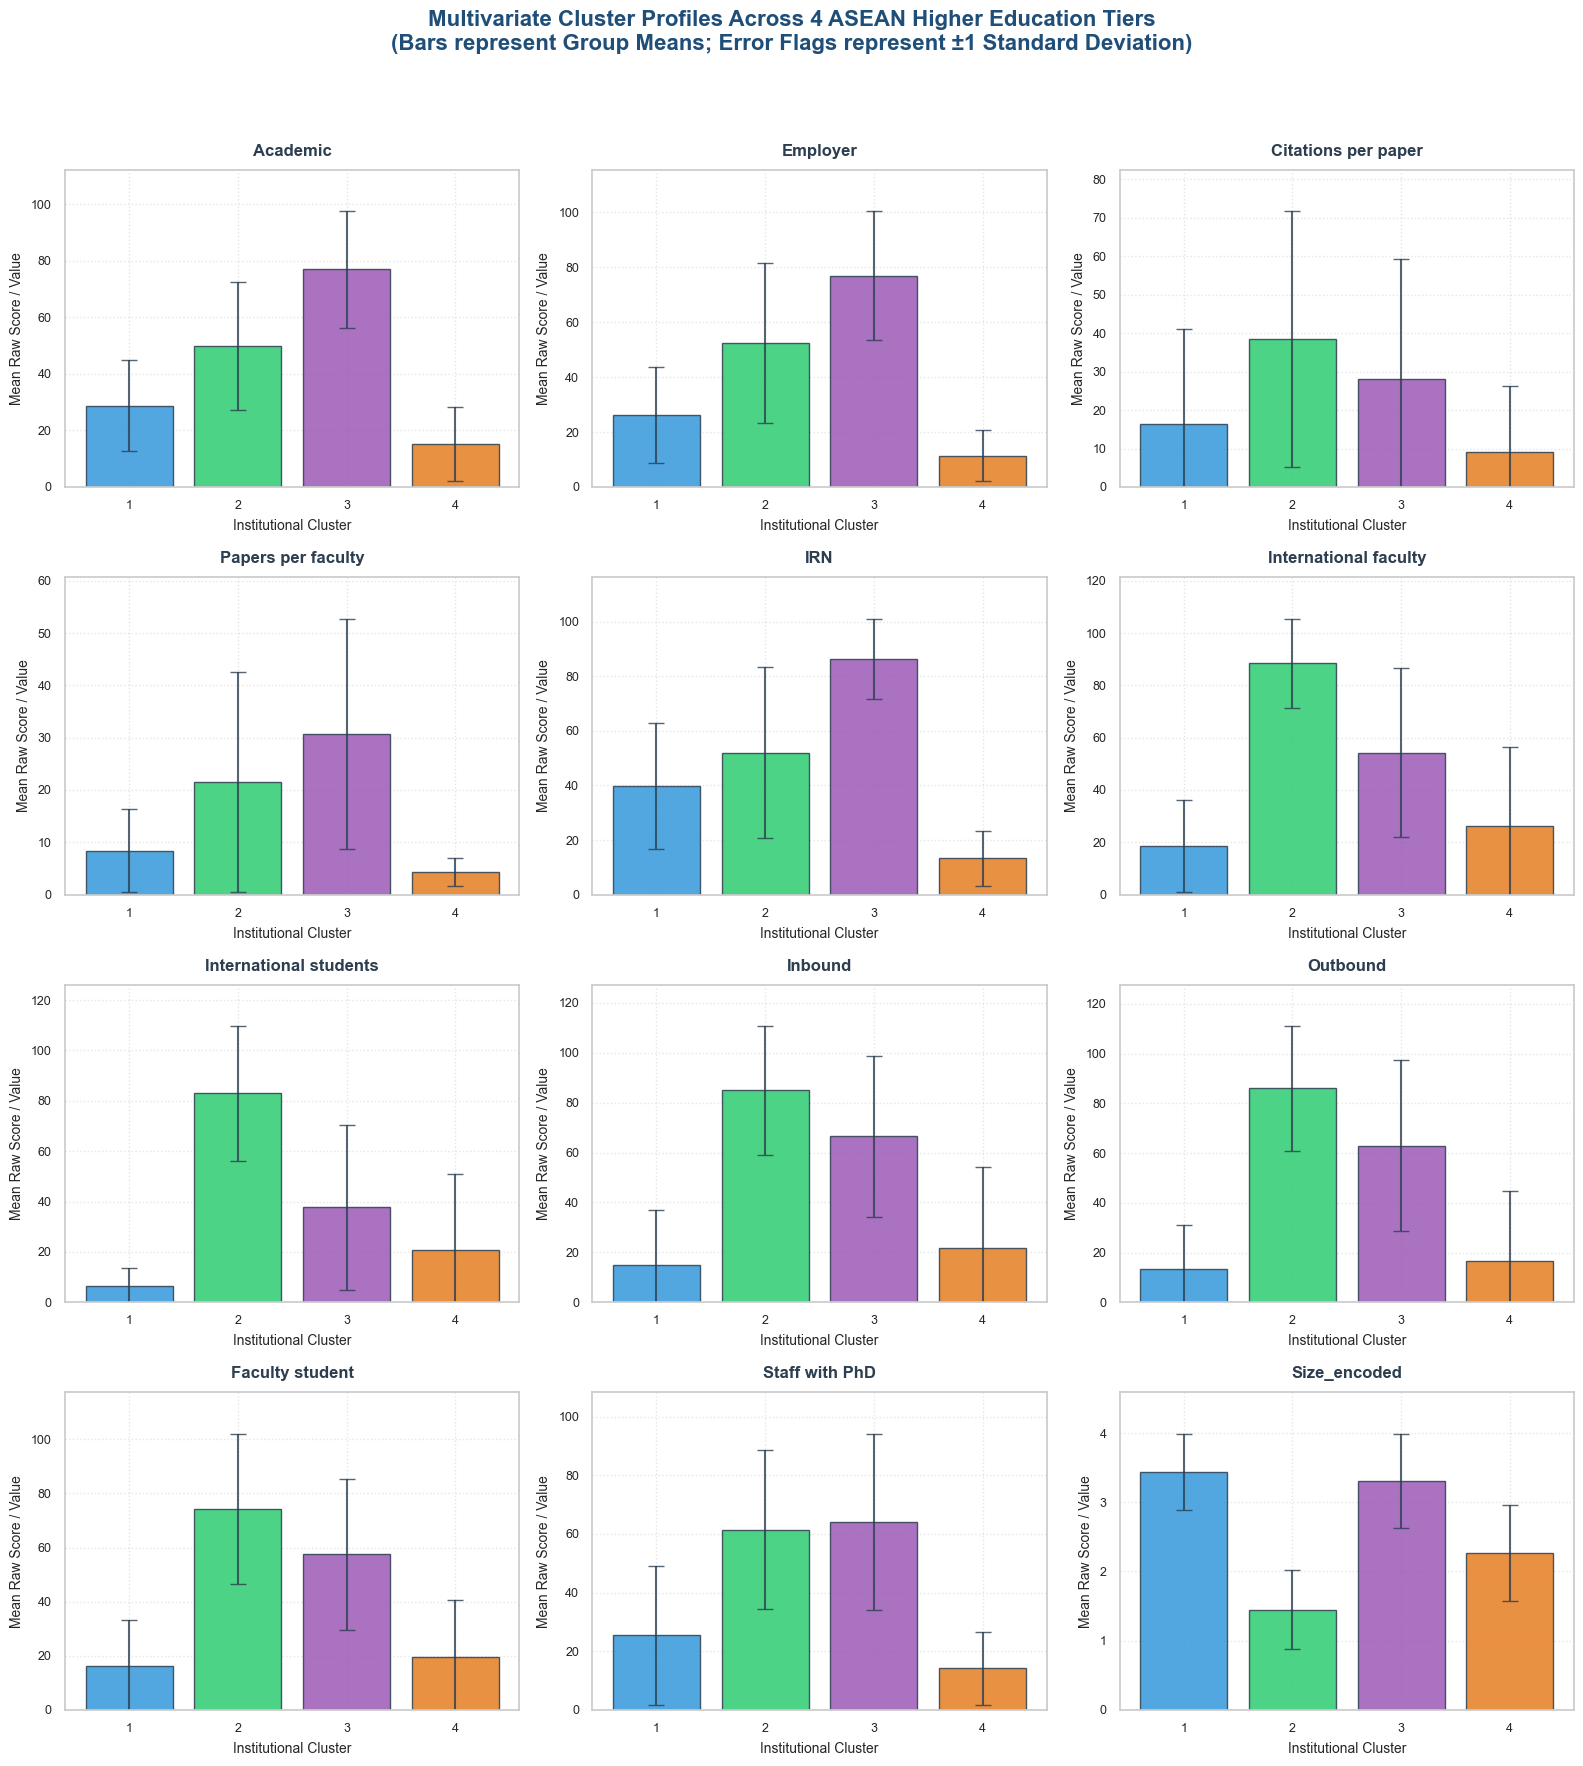

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. VERIFY DATA INTEGRITY ---
# Ensure independent features are mapped identically to your main pipeline
independent_features = [
    'Academic', 'Employer',                           # Reputational
    'Citations per paper', 'Papers per faculty',       # Research
    'IRN', 'International faculty', 'International students',
    'Inbound', 'Outbound',                             # Internationalization
    'Faculty student', 'Staff with PhD',               # Capacity
    'Size_encoded'                                     # Structure
]

# --- 2. COMPUTE MULTIVARIATE DESCRIPTIVE STATISTICAL MATRICES ---
# Aggregate means and standard deviations dynamically for all 4 clusters
cluster_profile = df.groupby('Assigned_Cluster')[independent_features].agg(['mean', 'std'])

print("="*90)
print("             CLUSTER DESCRIPTIVE PROFILES (MEAN ± STANDARD DEVIATION)       ")
print("="*90)
for feature in independent_features:
    print(f"\n--- Feature: {feature.upper()} ---")
    for cluster in sorted(df['Assigned_Cluster'].unique()):
        m = cluster_profile.loc[cluster, (feature, 'mean')]
        s = cluster_profile.loc[cluster, (feature, 'std')]
        print(f"  Cluster {cluster}: Mean = {m:6.2f} | Std Dev = {s:6.2f}")
print("="*90 + "\n")

# --- 3. CONSTRUCT HIGH-RESOLUTION FACETED COHORT PLOT ---
# Set up a 4-row, 3-column visualization canvas for the 12 indicators
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()  # Flatten matrix into an iterable 1D array

# Maintain strict color synchronization with your 4-cluster map
cluster_colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22']
cluster_labels = [f"Cluster {i}" for i in sorted(df['Assigned_Cluster'].unique())]

sns.set_theme(style="whitegrid")

for idx, feature in enumerate(independent_features):
    ax = axes[idx]

    # Extract mean vectors and standard deviation boundaries per group
    means = cluster_profile[feature]['mean']
    stds = cluster_profile[feature]['std']
    x_positions = [str(c) for c in means.index]

    # Generate the bar layout with explicit standard deviation error bars
    bars = ax.bar(
        x_positions,
        means.values,
        yerr=stds.values,
        capsize=6,
        error_kw={'ecolor': '#2c3e50', 'linewidth': 1.5, 'alpha': 0.8},
        color=cluster_colors,
        alpha=0.85,
        edgecolor='#2c3e50',
        linewidth=1.0
    )

    # Polishing subplot architectures
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold', pad=10, color='#2c3e50')
    ax.set_xlabel('Institutional Cluster', fontsize=10, labelpad=5)
    ax.set_ylabel('Mean Raw Score / Value', fontsize=10, labelpad=5)
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(True, linestyle=':', alpha=0.5, color='#cccccc')

    # Softly pad the y-axis ceiling to ensure error caps never clip the borders
    if means.values.max() > 0:
        ax.set_ylim(0, (means.values + stds.fillna(0).values).max() * 1.15)

# Add master layout metadata
plt.suptitle('Multivariate Cluster Profiles Across 4 ASEAN Higher Education Tiers\n(Bars represent Group Means; Error Flags represent ±1 Standard Deviation)',
             fontsize=16, fontweight='bold', y=0.98, color='#1f4e79')

plt.tight_layout(rect=[0, 0, 1, 0.95])

# --- 4. EXPORT GRAPHICS FOR PRESENTATION ---
output_visual_path = "asean_clusters_variance_profile.png"
plt.savefig(output_visual_path, dpi=300, bbox_inches='tight')
print(f"Success! Faceted variance profile saved as high-res chart: '{output_visual_path}'")

The code below runs one-way ANOVA to determine whether the observed differences for each variable for each cluster are statistically significant. The results of the one-way ANOVA are reported in the table below and likewise visualized in the following graphs.

In [26]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# =====================================================================
# 1. SETUP LOGICAL DATA RELATIONSHIPS
# =====================================================================
independent_features = [
    'Academic', 'Employer',                           # Reputational
    'Citations per paper', 'Papers per faculty',       # Research
    'IRN', 'International faculty', 'International students',
    'Inbound', 'Outbound',                             # Internationalization
    'Faculty student', 'Staff with PhD',               # Capacity
    'Size_encoded'                                     # Structure
]

# Ensure cluster labels from K-means are appended back to your imputed dataframe
X_imputed['Assigned_Cluster'] = df['Assigned_Cluster']

print("="*90)
print("       STAGE 1: ONE-WAY ANOVA SUMMARY REPORT (ALL 12 STRATEGIC METRICS)      ")
print("="*90)
print(f"{'Metric':<25} | {'F-Statistic':<12} | {'p-Value':<12} | {'Statistical Significance'}")
print("-"*90)

# Run One-Way ANOVA dynamically across all variables
for feature in independent_features:
    groups = [group_df[feature].values for name, group_df in X_imputed.groupby('Assigned_Cluster')]
    f_stat, p_val = stats.f_oneway(*groups)

    significance = "Not Significant"
    if p_val < 0.001:
        significance = "Highly Significant (p < 0.001) ***"
    elif p_val < 0.01:
        significance = "Significant (p < 0.01) **"
    elif p_val < 0.05:
        significance = "Significant (p < 0.05) *"

    print(f"{feature:<25} | {f_stat:<12.4f} | {p_val:<12.4e} | {significance}")

print("="*90 + "\n")


# =====================================================================
# 2. RUN TUKEY HSD NATIVELY (BYPASSING TEXT-PARSING BOTTLENECKS)
# =====================================================================
print("="*90)
print("       STAGE 2: COMPILING ALL-VARIABLE PAIRWISE POST-HOC MATRICES     ")
print("="*90)
print("Processing all 72 individual pair structural checks instantly...\n")

posthoc_rows = []

# Get the sorted unique list of clusters to track pair names accurately
unique_groups = sorted(X_imputed['Assigned_Cluster'].unique())
num_groups = len(unique_groups)

# Pre-calculate the exact pair names in the order statsmodels outputs them
pair_names = []
for i in range(num_groups):
    for j in range(i + 1, num_groups):
        pair_names.append(f"Cluster {unique_groups[i]} vs {unique_groups[j]}")

for feature in independent_features:
    # Execute the pairwise comparison engine natively
    tukey = pairwise_tukeyhsd(
        endog=X_imputed[feature],
        groups=X_imputed['Assigned_Cluster'],
        alpha=0.05
    )

    # Access the underlying raw numpy float arrays directly
    raw_p_values = tukey.pvalues
    raw_reject_flags = tukey.reject

    # Match the metrics directly to their respective pre-calculated pair slots
    for idx, pair_label in enumerate(pair_names):
        p_val = raw_p_values[idx]
        is_significant = raw_reject_flags[idx]

        status_string = f"Sig (p={p_val:.4f})" if is_significant else f"NS (p={p_val:.4f})"

        posthoc_rows.append({
            'Metric': feature,
            'Pair': pair_label,
            'Status': status_string
        })

# Create clean tracking dataframe
master_posthoc_df = pd.DataFrame(posthoc_rows)

# =====================================================================
# 3. GENERATE THE MASTER ACADEMIC SYNTHESIS MATRIX
# =====================================================================
synthesis_matrix = master_posthoc_df.pivot(
    index='Metric',
    columns='Pair',
    values='Status'
).reindex(independent_features)

print("="*125)
print("                  MASTER POST-HOC SYNTHESIS MATRIX")
print("="*125)
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(synthesis_matrix)
print("="*125 + "\n")

# =====================================================================
# 4. EXPORT COPIES FOR THESIS ARCHIVING
# =====================================================================
output_excel_path = "posthoc_master_synthesis_table.xlsx"
synthesis_matrix.to_excel(output_excel_path)
print(f"Success! Master Post-HOC matrix exported cleanly to Excel format at: '{output_excel_path}'\n")

       STAGE 1: ONE-WAY ANOVA SUMMARY REPORT (ALL 12 STRATEGIC METRICS)      
Metric                    | F-Statistic  | p-Value      | Statistical Significance
------------------------------------------------------------------------------------------
Academic                  | 144.9868     | 1.6168e-54   | Highly Significant (p < 0.001) ***
Employer                  | 147.6278     | 3.8383e-55   | Highly Significant (p < 0.001) ***
Citations per paper       | 13.5300      | 3.2750e-08   | Highly Significant (p < 0.001) ***
Papers per faculty        | 53.1804      | 1.2114e-26   | Highly Significant (p < 0.001) ***
IRN                       | 143.3659     | 3.9402e-54   | Highly Significant (p < 0.001) ***
International faculty     | 79.5828      | 3.2831e-36   | Highly Significant (p < 0.001) ***
International students    | 76.5619      | 3.3887e-35   | Highly Significant (p < 0.001) ***
Inbound                   | 67.4456      | 5.1076e-32   | Highly Significant (p < 0.001) ***
Outb

       GENERATING ACADEMIC SIGNIFICANCE BOXPLOT CHART MATRIX...             
Success! Faceted boxplot significance matrix saved as high-res chart: 'asean_tiers_anova_posthoc_stars.png'



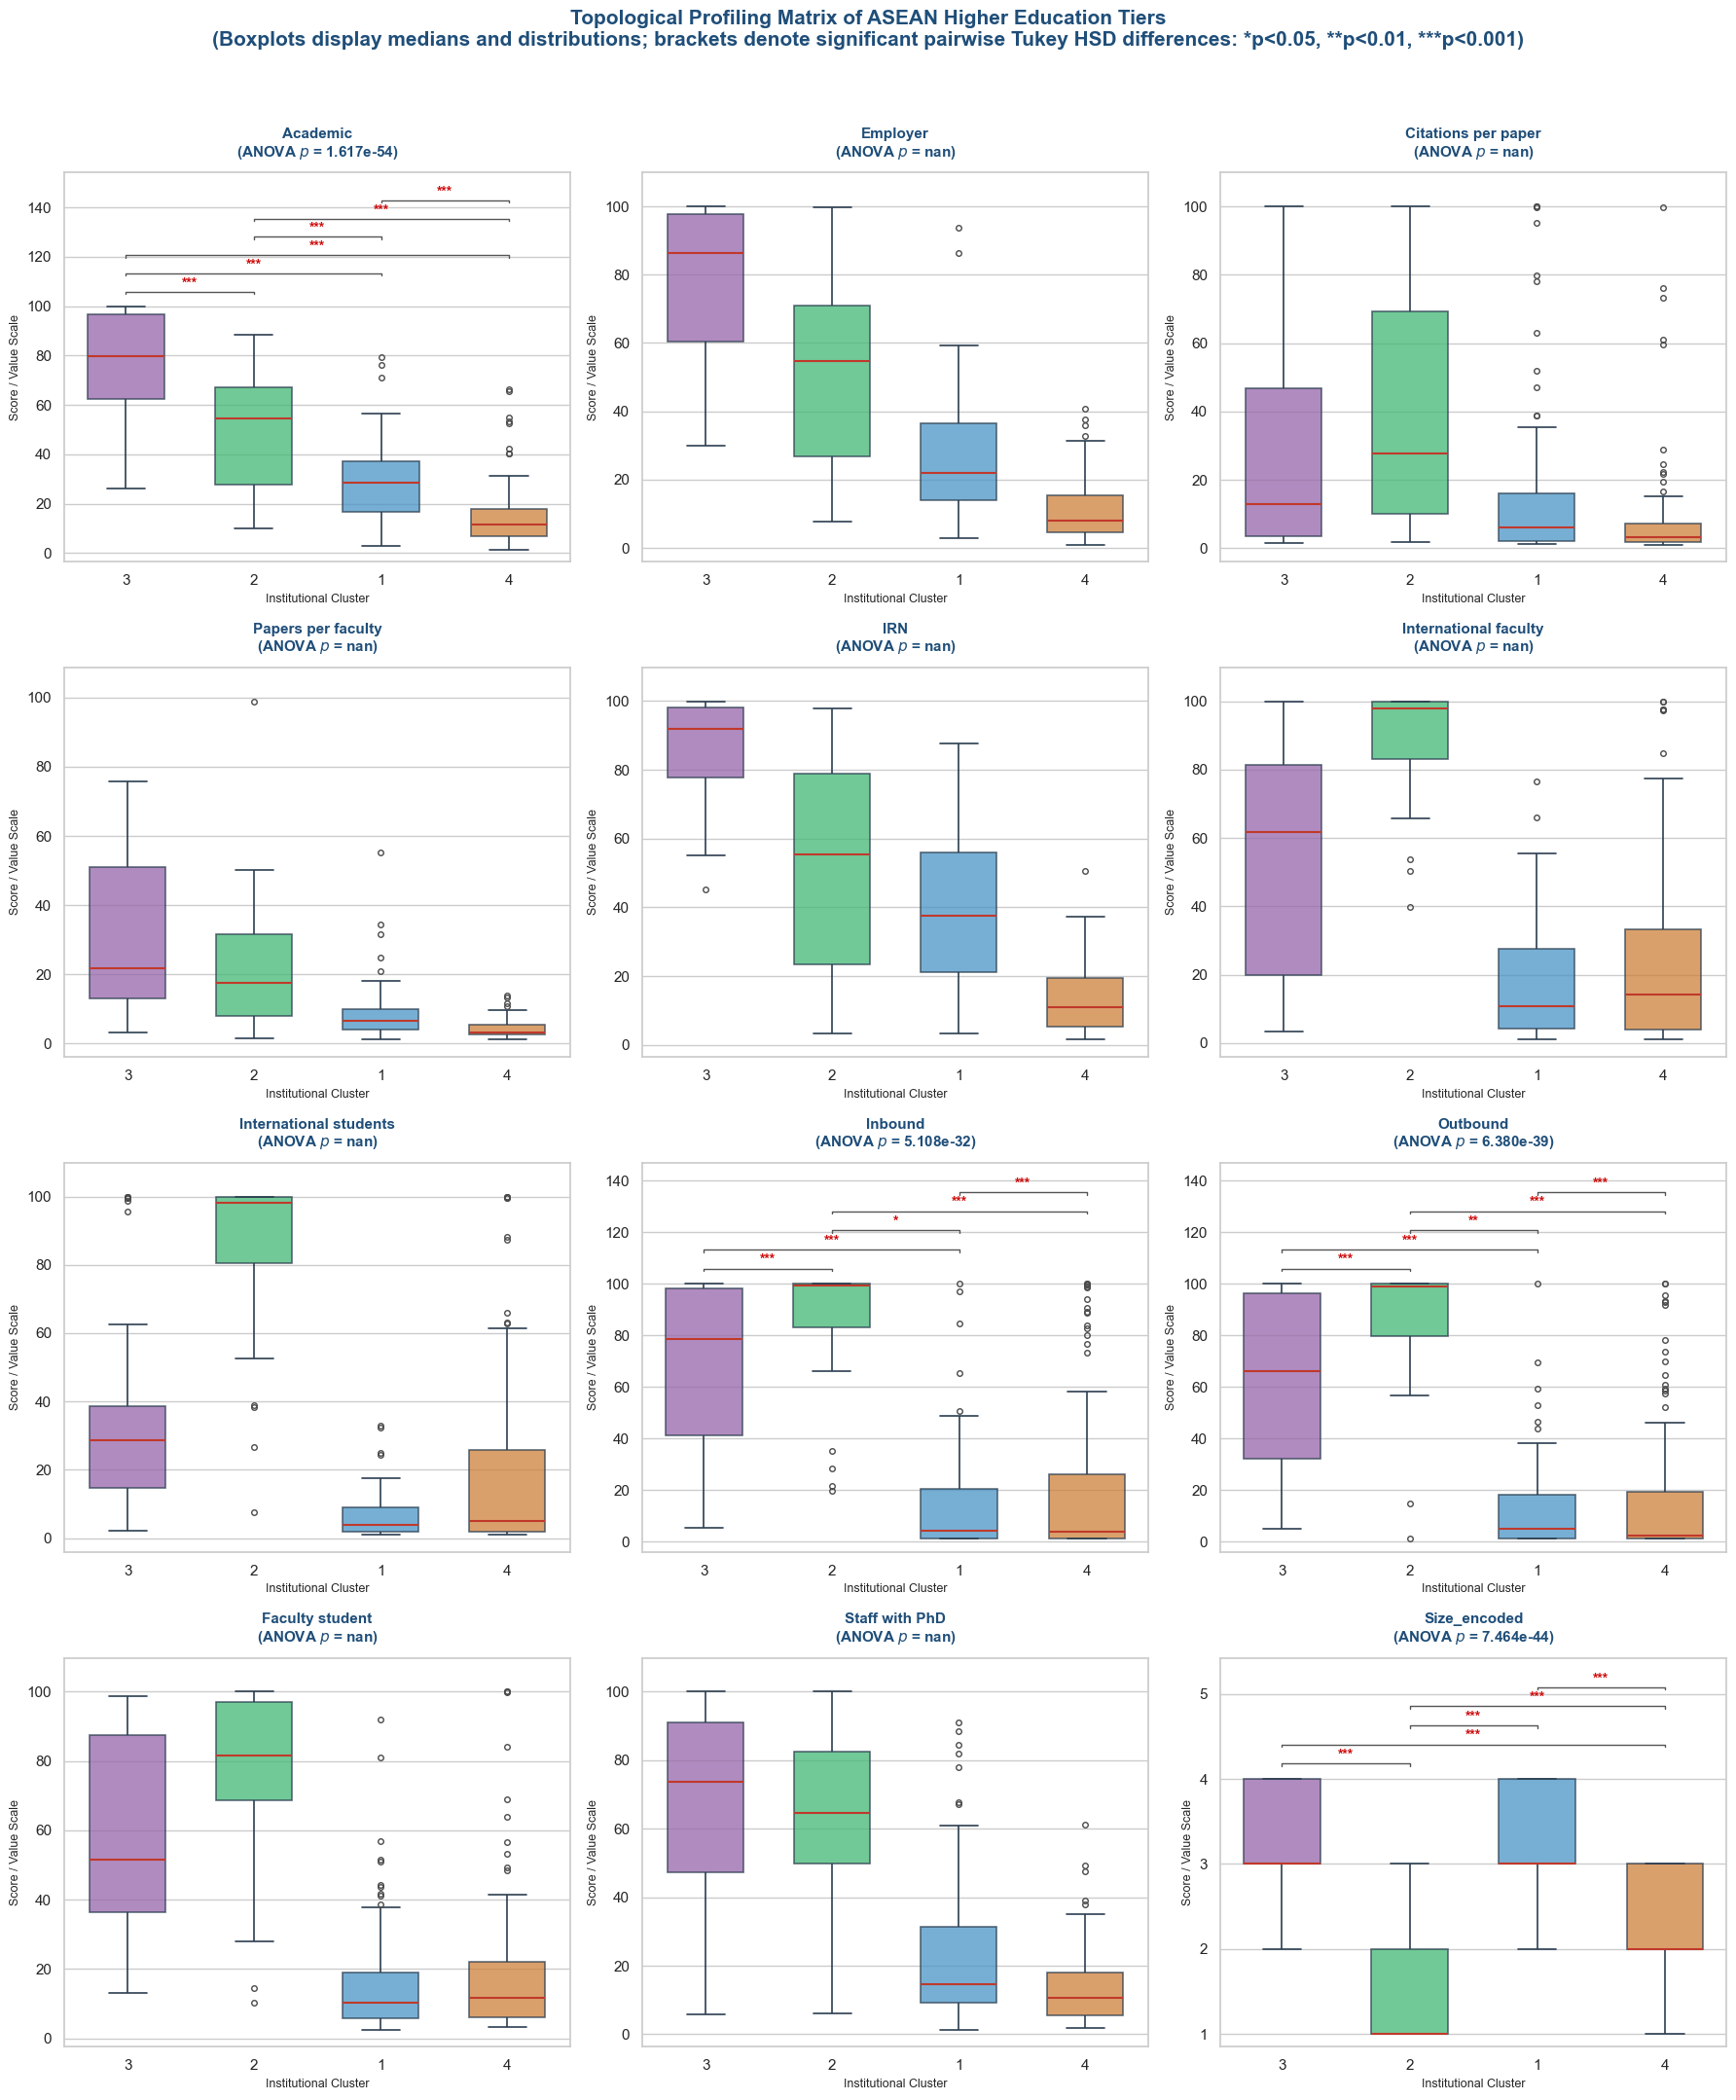

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- 1. SET UP FEATURE SCOPE ---
independent_features = [
    'Academic', 'Employer',                           # Reputational
    'Citations per paper', 'Papers per faculty',       # Research
    'IRN', 'International faculty', 'International students',
    'Inbound', 'Outbound',                             # Internationalization
    'Faculty student', 'Staff with PhD',               # Capacity
    'Size_encoded'                                     # Structure
]

# Guarantee the column values are uniform strings to align perfectly with the Seaborn update
df['Assigned_Cluster'] = df['Assigned_Cluster'].astype(str)
sorted_clusters = sorted(df['Assigned_Cluster'].unique())

sns.set_theme(style="whitegrid")

# --- 2. INITIALIZE MASTER CANVAS ---
fig, axes = plt.subplots(4, 3, figsize=(18, 22))
axes = axes.flatten()

# CRITICAL FIX: The palette keys are rewritten as strings to match modern Seaborn categorical lookup logic
cluster_palette = {'1': '#3498db', '2': '#2ecc71', '3': '#9b59b6', '4': '#e67e22'}

print("="*90)
print("       GENERATING ACADEMIC SIGNIFICANCE BOXPLOT CHART MATRIX...             ")
print("="*90)

for idx, feature in enumerate(independent_features):
    ax = axes[idx]

    # A. Execute Dynamic ANOVA for the Subplot Header
    groups_data = [gdf[feature].values for _, gdf in df.groupby('Assigned_Cluster')]
    f_stat, anova_p = stats.f_oneway(*groups_data)

    # B. Generate Base Boxplot (Explicit modern categorical parameters applied)
    sns.boxplot(
        data=df,
        x='Assigned_Cluster',
        y=feature,
        hue='Assigned_Cluster',       # Explicitly link hue mapping to prevent version warning blocks
        palette=cluster_palette,
        ax=ax,
        width=0.6,
        fliersize=4,
        linewidth=1.2,
        legend=False,                 # Suppress automated legends inside tight individual subplots
        boxprops=dict(alpha=0.75, edgecolor='#2c3e50'),
        whiskerprops=dict(color='#2c3e50'),
        capprops=dict(color='#2c3e50'),
        medianprops=dict(color='#c0392b', linewidth=1.5)
    )

    # C. Calculate Tukey HSD Post-Hoc Data Natively
    tukey = pairwise_tukeyhsd(endog=df[feature], groups=df['Assigned_Cluster'], alpha=0.05)

    # D. Format Dynamic Header with ANOVA Results
    ax.set_title(f"{feature}\n(ANOVA $p$ = {anova_p:.3e})", fontsize=11, fontweight='bold', pad=12, color='#1f4e79')
    ax.set_xlabel('Institutional Cluster', fontsize=9, labelpad=4)
    ax.set_ylabel('Score / Value Scale', fontsize=9, labelpad=4)

    # E. Bracket Annotation Engine for Post-Hoc Significance Stars
    y_max = df[feature].max()
    y_range = y_max - df[feature].min()

    bracket_level = 1.05

    pair_idx = 0
    for i in range(len(sorted_clusters)):
        for j in range(i + 1, len(sorted_clusters)):
            c1 = sorted_clusters[i]
            c2 = sorted_clusters[j]

            p_adj = tukey.pvalues[pair_idx]
            reject = tukey.reject[pair_idx]
            pair_idx += 1

            if reject or p_adj < 0.05:
                if p_adj < 0.001:
                    stars = "***"
                elif p_adj < 0.01:
                    stars = "**"
                else:
                    stars = "*"

                annotation_y = y_max + (y_range * (bracket_level - 1.0))
                line_height = annotation_y + (y_range * 0.01)

                x1_pos = sorted_clusters.index(c1)
                x2_pos = sorted_clusters.index(c2)

                ax.plot([x1_pos, x1_pos, x2_pos, x2_pos],
                        [annotation_y, line_height, line_height, annotation_y],
                        color='#555555', linewidth=1.0)

                ax.text((x1_pos + x2_pos) * 0.5, line_height + (y_range * 0.005),
                        stars, ha='center', va='bottom', color='#cc0000',
                        fontweight='bold', fontsize=10)

                bracket_level += 0.075

    ax.set_ylim(df[feature].min() - (y_range * 0.05), y_max + (y_range * (bracket_level - 0.95)))

# Add Master Layout Labels
plt.suptitle('Topological Profiling Matrix of ASEAN Higher Education Tiers\n(Boxplots display medians and distributions; brackets denote significant pairwise Tukey HSD differences: *p<0.05, **p<0.01, ***p<0.001)',
             fontsize=15, fontweight='bold', y=0.98, color='#1f4e79')

plt.tight_layout(rect=[0, 0, 1, 0.96])

# --- 3. EXPORT CAPSTONE GRAPHICS ---
output_chart_name = "asean_tiers_anova_posthoc_stars.png"
plt.savefig(output_chart_name, dpi=300, bbox_inches='tight')
print(f"Success! Faceted boxplot significance matrix saved as high-res chart: '{output_chart_name}'\n")

plt.show()

### **Discussion on K-means clustering results**
Instead of a simple ranking ladder, the 4 clusters reveal that ASEAN HEIs are divided into distinct operational archetypes.

**Tier 1 (Cluster 3): the global flagship of ASEAN HEIs**

Universities in this tier include National University of Singapore, Nanyang Technological University, and the University of Malaya. These universities lead not only in the ASEAN region but also globally. This cluster is characterized by strong scores in academic and employer reputation, as well as in the international research network.

**Tier 2 (Cluster 2): the intensive research institutions**

ASEAN HEIs in this tier are display highly competitive research metrics, specifically Citations per paper and Papers per faculty, that often rival Tier 1. However, their Academic and Employer reputation scores sit at a moderate baseline. The top Philippine universities are in this tier, together wih familiar ASEAN institutions such as Kasetsart University.

**Tier 3 (Cluster 1): the national megastructures**

The universities in this tier are large in terms of physical size and include historic state and national universities. This tier lags behind the first two tiers but has strong potential to catch up.

**Tier 4 (Cluster 4): the regional emergents**

The HEIs in this tier display the lowest scores in all variables. This tier represents the critical foundational base of ASEAN's human capital infrastructure. Their operational mandate is not global research prestige, but local teaching, workforce readiness, and localized access to higher education.




### **Penalized logistic regression**
#### Relevant modules: 4 & 6
The next phase in the study was to fit a penalized logistic regression in to the ranking data. While k-means clustering revealed segmentation among ASEAN universities, it provides little insights on the drivers of the rankings. Thus, the output of the logistic regression model is identifying which specific operational metrics most heavily drive a university's probability of breaking into a top tier. For a university administrator, this information is valuable since it can guide strategy and prioritize key areas which will give the most return on investment.

As stated in the data dictionary, the ranking of the universities was used as the basis of creating classes which serves as the target variable for the logistic regression model. Universities that belong to rank 1 (highest) to 700 are categorized to Class A. On the other hand, universities that belong to rank 701 to 1500+ are categorized to Class B. It should be noted that after the 700th rank, universities are no longer individually ranked but instead are banded together within a ranking range. For example, Siam University and Ubon Ratchathani University are both ranked in the 851 - 900 range.

Given that the primary objective of this study is explanatory inference—specifically, identifying the drivers of university rankings—rather than out-of-sample predictive accuracy, the penalized logistic regression model was fit utilizing the complete regional dataset (N=255). A traditional training-and-testing validation split was intentionally bypassed to maximize statistical power.  To mitigate the risks of overfitting and coefficient instability which can be expected with highly collinear parameters, regularization penalties were applied. This thus ensures that the calculated feature weights reflect robust structural relationships. It should likewise be noted that unlike in the k-means clustering model, the penalized logistic regression model employed k-nn imputation to fill in missing values.




          ADVANCED MODEL PERFORMANCE METRICS REPORT
• Log Loss (Cross-Entropy)        : 0.1212
• Precision-Recall AUC (PR-AUC)   : 0.9928
• Confusion Matrix Breakdown:
    - True Negatives (Correct B)  : 132
    - False Positives (Type I Er) : 1
    - False Negatives (Type II Er): 11
    - True Positives (Correct A)  : 111

--- DETAILED CLASSIFICATION REPORT ---
                  precision    recall  f1-score   support

Class B (Banded)       0.92      0.99      0.96       133
Class A (Ranked)       0.99      0.91      0.95       122

        accuracy                           0.95       255
       macro avg       0.96      0.95      0.95       255
    weighted avg       0.96      0.95      0.95       255


       DERIVED INSTITUTIONAL WEIGHTS (RANKED BY REGIONAL ROI)
             Indicator Log_Coefficient (Beta) Odds_Ratio
              Academic                 3.0598     21.32x
              Employer                 2.0215      7.55x
                   IRN                 1.3416    

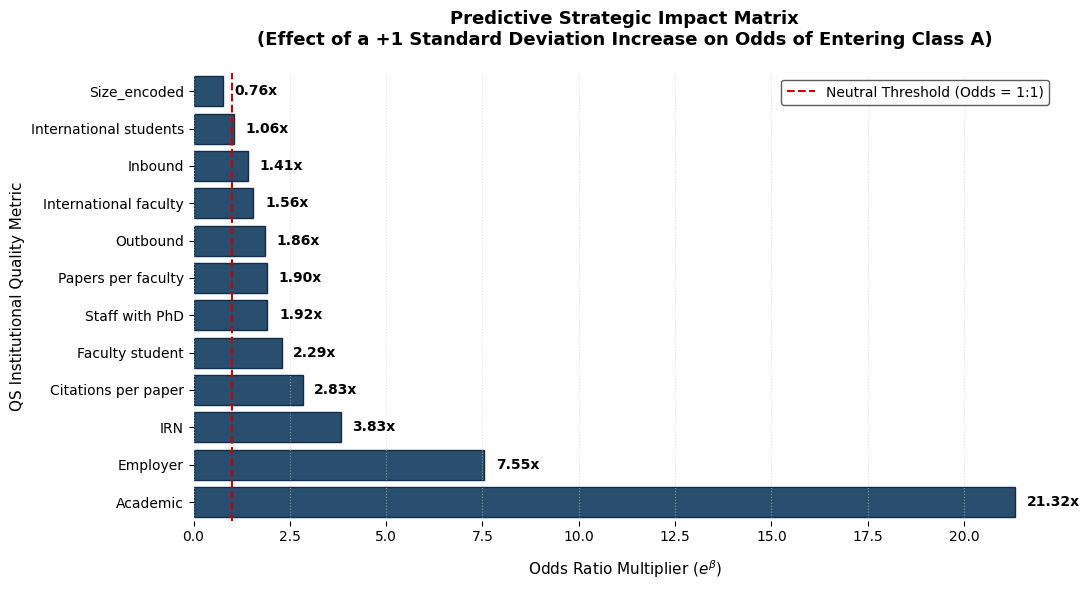

In [35]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

# --- 1. GLOBAL INITIALIZATION & SETUP ---
warnings.filterwarnings("ignore")
os.chdir("/Users/COS/Documents/AIM/Capstone")

# --- 2. DATA INGESTION & FEATURE ENCODING ---
try:
    df = pd.read_csv("qs.csv", encoding="latin1")
except UnicodeDecodeError:
    df = pd.read_csv("qs.csv", encoding="cp1252")

# Create binary targets and encode ordinal features
df["Target"] = df["Class"].map({"A": 1, "B": 0})
df["Size_encoded"] = df["Size"].map({"S": 1, "M": 2, "L": 3, "XL": 4})

feature_cols = [
    "Academic",
    "Employer",
    "Faculty student",
    "IRN",
    "Citations per paper",
    "Papers per faculty",
    "Staff with PhD",
    "International faculty",
    "International students",
    "Inbound",
    "Outbound",
    "Size_encoded",
]

X = df[feature_cols].copy()
y = df["Target"]

# --- 3. ALGORITHMIC PREPROCESSING PIPELINE ---
imputer = KNNImputer(n_neighbors=3, weights="distance")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Instantiate our regularized classification engine
model = LogisticRegression(penalty="l2", random_state=42, max_iter=1000)

# =====================================================================
# PHASE I: STRATIFIED CROSS-VALIDATION DIAGNOSTICS
# =====================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generate cross-validated predictions and probabilities
y_pred_cv = cross_val_predict(model, X_scaled, y, cv=cv, method="predict")
y_pred_proba_cv = cross_val_predict(
    model, X_scaled, y, cv=cv, method="predict_proba"
)[:, 1]

# Compute rigorous evaluation metrics
cv_log_loss = log_loss(y, y_pred_proba_cv)
precision_vals, recall_vals, _ = precision_recall_curve(y, y_pred_proba_cv)
pr_auc = auc(recall_vals, precision_vals)
tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()

# Print metrics directly to the console
print("\n" + "=" * 60)
print("          ADVANCED MODEL PERFORMANCE METRICS REPORT")
print("=" * 60)
print(f"• Log Loss (Cross-Entropy)        : {cv_log_loss:.4f}")
print(f"• Precision-Recall AUC (PR-AUC)   : {pr_auc:.4f}")
print("• Confusion Matrix Breakdown:")
print(f"    - True Negatives (Correct B)  : {tn}")
print(f"    - False Positives (Type I Er) : {fp}")
print(f"    - False Negatives (Type II Er): {fn}")
print(f"    - True Positives (Correct A)  : {tp}")
print("=" * 60)
print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(
    classification_report(
        y, y_pred_cv, target_names=["Class B (Banded)", "Class A (Ranked)"]
    )
)
print("=" * 60 + "\n")


# =====================================================================
# PHASE II: FULL EXTRACTION, TABULATION & STRATEGIC PLOTTING
# =====================================================================
# Fit the model on 100% of the dataset to extract stable coefficients
model.fit(X_scaled, y)

# Construct sorted structural table of weights
results_table = pd.DataFrame(
    {
        "Indicator": feature_cols,
        "Log_Coefficient (Beta)": model.coef_[0],
        "Odds_Ratio": np.exp(model.coef_[0]),
    }
).sort_values(by="Odds_Ratio", ascending=False)  # Descending for tabular readability

# --- NEW: PRINT THE ODDS RATIO TABULATION REPORT ---
print("=" * 65)
print("       DERIVED INSTITUTIONAL WEIGHTS (RANKED BY REGIONAL ROI)")
print("=" * 65)
print(
    results_table.to_string(
        index=False,
        formatters={
            "Log_Coefficient (Beta)": "{:,.4f}".format,
            "Odds_Ratio": "{:,.2f}x".format,
        },
    )
)
print("=" * 65 + "\n")


# Sort ascending for a clean top-down plot layout (highest at the top)
results_table = results_table.sort_values(by="Odds_Ratio", ascending=True)

# Force clear white plotting parameters
plt.style.use("default")
plt.rcParams.update(
    {
        "figure.facecolor": "#FFFFFF",
        "figure.edgecolor": "#FFFFFF",
        "axes.facecolor": "#FFFFFF",
        "savefig.facecolor": "#FFFFFF",
        "savefig.edgecolor": "#FFFFFF",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
    }
)

fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")
ax.set_facecolor("white")

# Render structural impact bars
sns.barplot(
    x="Odds_Ratio",
    y="Indicator",
    data=results_table,
    color="#1f4e79",
    edgecolor="#0f2d4a",
    ax=ax,
)

# Plot the 1:1 threshold axis marker
ax.axvline(
    x=1.0,
    color="#cc0000",
    linestyle="--",
    linewidth=1.5,
    label="Neutral Threshold (Odds = 1:1)",
)

# Annotate values alongside the bars
for i, row in enumerate(results_table.itertuples()):
    ax.text(
        row.Odds_Ratio + 0.3,
        i,
        f"{row.Odds_Ratio:.2f}x",
        va="center",
        color="black",
        fontweight="bold",
        fontsize=10,
    )

# Visual polishing
ax.set_title(
    "Predictive Strategic Impact Matrix\n(Effect of a +1 Standard Deviation Increase on Odds of Entering Class A)",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="black",
)
ax.set_xlabel("Odds Ratio Multiplier ($e^\\beta$)", fontsize=11, labelpad=10)
ax.set_ylabel("QS Institutional Quality Metric", fontsize=11)
ax.grid(axis="x", linestyle=":", alpha=0.6, color="#cccccc")
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#333333")

sns.despine(left=True, bottom=True)
plt.tight_layout()

# Export clean copy to your working directory
plt.savefig(
    "odds_ratio_impact_chart.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
)
plt.show()

The results show that the penalized logistic regression model excellently fits the data of the categorized 255 ASEAN universities, as supported by AUC and F1 scores that are greater than 0.9. The next step is determining the odds ratio of the variables to determine which among them have the largest impact in moving up the rankings.

### **Model Diagnostics**
The assumptions of the logistic regression model were checked by calculating the Variance Inflation Factor (VIF) and checking for the linearity of the log-odds of the coefficients through the Box - Tidwell test. VIF results show that all variables are within the tolerable limit of less than 10, although the two variables Academic and Employer Reputation have VIF scores of 7. This indicates multicollinearity wherein the variance of these two variables can be explained by the other variables.

For the results of the Box - Tidwell test, the interaction terms that have p-values greater than 0.05 confirm that the linearity assumption for that particular variable is met. Even though some variables in the model violated the linearity assumption, using the L2/L1 regularization addresses this factor, together with the moderate VIF scores. Regularization penalizes these variables and shrinks coefficient variance, effectively absorbing these localized non-linear fluctuations. This approach preserves the immediate, intuitive interpretability of standard odds ratios while ensuring the model remains robust against overfitting


             ADVANCED MODEL ROBUSTNESS & AUDIT REPORT

1. VARIANCE INFLATION FACTORS (VIF)
---------------------------------------------------------------------------
               Feature  VIF
              Academic 7.34
              Employer 6.21
                   IRN 4.95
              Outbound 4.73
               Inbound 4.25
International students 2.96
 International faculty 2.75
        Staff with PhD 2.71
       Faculty student 2.69
    Papers per faculty 2.62
          Size_encoded 1.96
   Citations per paper 1.76

* Insight: VIF > 5.0-10.0 confirms heavy feature correlation,
  mathematically validating why an L2 (Ridge) penalty is required.


2. BOX-TIDWELL LINEARITY INTERACTION COHORT ANALYSIS (UNIVARIATE FIX)
---------------------------------------------------------------------------
                                   Interaction Term Interaction Weight (Beta) p-value
                              Inbound * ln(Inbound)                   -0.0472  0.0001
                  

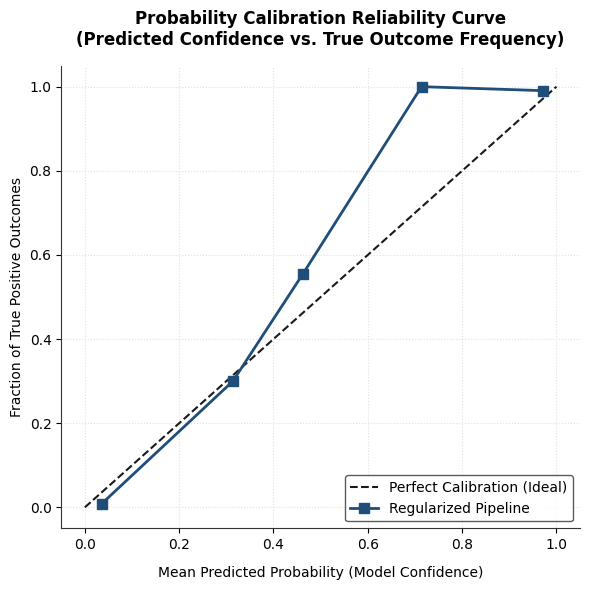

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.calibration import calibration_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure X_scaled is structured as a DataFrame with named features for proper reporting
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

# =====================================================================
# DIAGNOSTIC 1: MULTICOLLINEARITY (VIF)
# =====================================================================
vif_data = pd.DataFrame()
vif_data["Feature"] = feature_cols
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled_df.values, i)
    for i in range(len(feature_cols))
]
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# =====================================================================
# DIAGNOSTIC 2: FIXED UNIVARIATE BOX-TIDWELL (LINEARITY IN LOG-ODDS)
# =====================================================================
X_imputed_df = pd.DataFrame(X_imputed, columns=feature_cols)
bt_results = []

# Test each continuous variable individually to eliminate separation and singularity
for col in feature_cols:
    # Isolate the base feature and generate its interaction term
    df_temp = pd.DataFrame({
        'X': X_imputed_df[col],
        'X_lnX': X_imputed_df[col] * np.log(X_imputed_df[col] + 1e-5)
    })
    df_temp = sm.add_constant(df_temp)

    try:
        # Fit univariate logistic model
        sm_model = sm.Logit(y, df_temp).fit(disp=0, maxiter=1000)
        beta_interaction = sm_model.params['X_lnX']
        p_val_interaction = sm_model.pvalues['X_lnX']
    except Exception:
        # Fallback solver if maximum likelihood struggles with a specific distribution
        try:
            sm_model = sm.Logit(y, df_temp).fit(method='bfgs', disp=0, maxiter=1000)
            beta_interaction = sm_model.params['X_lnX']
            p_val_interaction = sm_model.pvalues['X_lnX']
        except Exception:
            beta_interaction = np.nan
            p_val_interaction = np.nan

    bt_results.append({
        "Interaction Term": f"{col} * ln({col})",
        "Interaction Weight (Beta)": beta_interaction,
        "p-value": p_val_interaction
    })

# Convert to DataFrame and sort by p-value to easily spot non-linear violations
bt_weights = pd.DataFrame(bt_results).sort_values(by="p-value", ascending=True)

# =====================================================================
# PRINT COMPLETE MODEL DIAGNOSTICS DISCOVERY REPORT
# =====================================================================
print("\n" + "=" * 75)
print("             ADVANCED MODEL ROBUSTNESS & AUDIT REPORT")
print("=" * 75)

print("\n1. VARIANCE INFLATION FACTORS (VIF)")
print("-" * 75)
print(vif_data.to_string(index=False, formatters={"VIF": "{:,.2f}".format}))
print("\n* Insight: VIF > 5.0-10.0 confirms heavy feature correlation,")
print("  mathematically validating why an L2 (Ridge) penalty is required.")

print("\n\n2. BOX-TIDWELL LINEARITY INTERACTION COHORT ANALYSIS (UNIVARIATE FIX)")
print("-" * 75)
print(bt_weights.to_string(index=False, formatters={
    "Interaction Weight (Beta)": "{:,.4f}".format,
    "p-value": "{:,.4f}".format
}))
print("\n* Insight: p-value >= 0.05 confirms steady, verified log-odds linearity.")
print("  p-value < 0.05 indicates statistically significant non-linear scaling trends.")
print("=" * 75 + "\n")

# =====================================================================
# DIAGNOSTIC 3: CALIBRATION CURVE PLOT RENDERING
# =====================================================================
prob_true, prob_pred = calibration_curve(y, y_pred_proba_cv, n_bins=5)

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "#FFFFFF",
    "axes.facecolor": "#FFFFFF",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "#333333"
})

fig_cal, ax_cal = plt.subplots(figsize=(6, 6), facecolor="white")
ax_cal.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect Calibration (Ideal)")
ax_cal.plot(
    prob_pred,
    prob_true,
    "s-",
    color="#1f4e79",
    linewidth=2,
    markersize=7,
    label="Regularized Pipeline"
)

ax_cal.set_title("Probability Calibration Reliability Curve\n(Predicted Confidence vs. True Outcome Frequency)",
                 fontsize=12, fontweight="bold", pad=15)
ax_cal.set_xlabel("Mean Predicted Probability (Model Confidence)", fontsize=10, labelpad=10)
ax_cal.set_ylabel("Fraction of True Positive Outcomes", fontsize=10)
ax_cal.grid(True, linestyle=":", alpha=0.6, color="#cccccc")
ax_cal.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="#333333")

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig("model_calibration_curve.png", dpi=300, facecolor=fig_cal.get_facecolor(), edgecolor="none")
plt.show()

### **Discussion on the Logistic Regression Results**

It should be emphasized again the model training and testing are not appropriate to be implemented due to the nature of the dataset and problem being addressed. Seeking to develop an inferential model which aims to **explain** the observed results, fitting a model on the entire dataset will yield more insights and maximize statistical power.

Key insights from the penalized logistic regression model can be derived from the odds ratio (OR). Since the variables are standardized and scaled, the OR for each variable can be interpreted as for OR greater than 1, *holding all other variables constant, every unit increase in standard deviation increases multiplies the odds of a university successfully moving from Class B into Class A*. The massive influence of Academic and Employer reputation, as denoted by OR = 21.32 and 7.55, respectively, is expected. In the ranking methodology published by QS, it is specifically stated that these two factors have the greatest weights in the ranking. For university leadership however, this information offers little actionable insight since reputation is a vague concept, with no straightforward answer on how to increase this score. An important finding of the regression model is that research impact is more important than research productivity, wherein the variable citations per paper has an OR of 2.83 compared to paper per faculty (OR = 1.90). This is a crucial insight since this suggests that university administrators should recalibrate existing incentive schemes to promote research quality over quantity. Another driver for upward ranking mobility is the variable international research network (OR = 3.83). This establishes that cross-border co-authorships and international collaborative grants are non-negotiable requirements for flagship status, acting as a vital catalyst to boost regional visibility.

## **Conclusion**
1) Top - ranked ASEAN universities have four segments - the global flagships, the research - oriented, the large, national and state universities, and finally, the local emergents.
2) It is impractical for a university to attempt all factors simultaneously. Administrators should focus on variables that offer the most return of investment. Based on the penalized logistic regression model, these variables citations per faculty and international research network.
3) Overall, the logistic regression model suggests that research quality is more important than quantity, and establishing a strong international research network is vital for moving up the rankings, especially for crossing into the upper tier.

## **Declaration of AI Use**
Google Gemini was used for AI - assisted code writing, brainstorming, and sentence improvement.


In [40]:
!jupyter nbconvert --to html notebook7.ipynb

[NbConvertApp] Converting notebook notebook7.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('jetTransient' was unexpected)

Failed validating 'additionalProperties' in display_data:

On instance['cells'][7]['outputs'][1]:
{'data': {'image/png': 'iVBORw0KGgoAAAANSUhEUgAAA90AAAHpCAYAAACful8UAAAAOXRFWHRTb2Z0d2Fy...',
          'text/plain': '<Figure size 1000x500 with 1 Axes>'},
 'jetTransient': {'display_id': None},
 'metadata': {},
 'output_type': 'display_data'}
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1510279 bytes to notebook7.html
